# Same-basis vs cross-basis correlations under two DEM decompositions

This notebook tests whether the correlated edges used by correlated matching can ever
link **two edges in the same basis subgraph** (X-X or Z-Z), or whether they are always
**cross-basis** (X-Z, the same-qubit Y-error mechanism).

We compare the two decompositions used in the project:

- **`decompose_errors=True`** - Stim's native error decomposition.
- **`decompose_errors_for_stim_surface_code_coords`** - the geometry-aware ("tesseract")
  decomposition that assigns every detector to the X or Z basis from its coordinates.

For each DEM we look at every multi-component (correlated) error instruction, map each
component to its detectors, classify each component's basis, and classify every induced
pairwise correlation edge as same-basis / cross-basis / mixed. This mirrors how
`DriftedMatchingEnv._build_line_graph_edges` builds the correlation (line) graph.

**Hypothesis:** the basis-aware decomposition yields only cross-basis correlations,
while Stim's native decomposition can also yield same-basis correlations.

In [1]:
import stim
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

from adaptiveQRL.decompose_errors import (
    decompose_errors_for_stim_surface_code_coords,
    detector_coord_to_basis_for_stim_surface_code_convention,
)

# --- parameters ---
DISTANCE = 5
ROUNDS = 5
P = 1e-3
print(f"distance={DISTANCE}, rounds={ROUNDS}, p={P}")

distance=5, rounds=5, p=0.001


In [2]:
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=DISTANCE,
    rounds=ROUNDS,
    after_clifford_depolarization=P,
    before_measure_flip_probability=P,
    after_reset_flip_probability=P,
    before_round_data_depolarization=P,
)

dem_stim = circuit.detector_error_model(decompose_errors=True)
dem_raw  = circuit.detector_error_model(decompose_errors=False)
dem_tess = decompose_errors_for_stim_surface_code_coords(dem_raw)

print("Stim-native DEM :", dem_stim.num_errors, "errors,", dem_stim.num_detectors, "detectors")
print("Tesseract  DEM :", dem_tess.num_errors, "errors,", dem_tess.num_detectors, "detectors")

Stim-native DEM : 1953 errors, 120 detectors
Tesseract  DEM : 1677 errors, 120 detectors


In [3]:
# Map each detector id -> basis label 'X' or 'Z' from its coordinates.
def build_basis_map(dem):
    coords = dem.get_detector_coordinates()
    bmap = {}
    for det_id, c in coords.items():
        b = detector_coord_to_basis_for_stim_surface_code_convention(c)  # 0 -> X, 1 -> Z
        bmap[det_id] = 'X' if b == 0 else 'Z'
    return bmap

# Split a DEM error instruction into components (tuples of detector ids), at '^' separators.
def parse_components(instruction):
    comps, cur = [], []
    for t in instruction.targets_copy():
        if t.is_separator():
            if cur:
                comps.append(tuple(sorted(cur)))
                cur = []
        elif t.is_relative_detector_id():
            cur.append(t.val)
        # logical-observable targets are ignored for basis classification
    if cur:
        comps.append(tuple(sorted(cur)))
    return comps

# Basis of a component: 'X', 'Z', 'mixed' (both bases) or 'none' (no detectors).
def component_basis(comp, bmap):
    bases = {bmap.get(d) for d in comp}
    bases.discard(None)
    if len(bases) == 1:
        return next(iter(bases))
    if not bases:
        return 'none'
    return 'mixed'

basis_map = build_basis_map(dem_raw)
print("detectors classified by basis:", dict(Counter(basis_map.values())))

detectors classified by basis: {'Z': 72, 'X': 48}


In [4]:
def analyze_dem(dem, bmap):
    dem = dem.flattened()
    n_errors = n_correlated = 0
    comp_count_hist = Counter()
    nongraphlike = 0          # components with > 2 detectors (not a graphlike edge)
    mixed_components = 0      # single components spanning both bases
    corr_edges = set()        # unique pairs of component-edges (mirrors the line graph)
    corr_class = Counter()
    same_basis_examples = []
    for inst in dem:
        if inst.type != 'error':
            continue
        n_errors += 1
        comps = parse_components(inst)
        comp_count_hist[len(comps)] += 1
        for c in comps:
            if len(c) > 2:
                nongraphlike += 1
            if component_basis(c, bmap) == 'mixed':
                mixed_components += 1
        if len(comps) < 2:
            continue
        n_correlated += 1
        for i in range(len(comps)):
            for j in range(i + 1, len(comps)):
                e1, e2 = comps[i], comps[j]
                if e1 == e2:
                    continue
                key = tuple(sorted((e1, e2)))
                if key in corr_edges:
                    continue
                corr_edges.add(key)
                b1, b2 = component_basis(e1, bmap), component_basis(e2, bmap)
                if b1 in ('mixed', 'none') or b2 in ('mixed', 'none'):
                    cls = 'mixed/other'
                elif b1 == b2:
                    cls = f'same-basis ({b1})'
                    if len(same_basis_examples) < 8:
                        same_basis_examples.append((str(inst), e1, b1, e2, b2))
                else:
                    cls = 'cross-basis'
                corr_class[cls] += 1
    return {
        'n_errors': n_errors,
        'n_correlated': n_correlated,
        'comp_count_hist': dict(sorted(comp_count_hist.items())),
        'nongraphlike_components': nongraphlike,
        'mixed_components': mixed_components,
        'n_unique_corr_edges': len(corr_edges),
        'corr_class': dict(corr_class),
        'same_basis_examples': same_basis_examples,
    }

res_stim = analyze_dem(dem_stim, basis_map)
res_tess = analyze_dem(dem_tess, basis_map)
print("done")

done


In [5]:
def summarize(name, r):
    print(f"==== {name} ====")
    print(f"  error instructions           : {r['n_errors']}")
    print(f"  correlated (multi-component) : {r['n_correlated']}")
    print(f"  components-per-error hist     : {r['comp_count_hist']}")
    print(f"  components with >2 detectors  : {r['nongraphlike_components']}")
    print(f"  components spanning 2 bases   : {r['mixed_components']}")
    print(f"  unique correlation edges      : {r['n_unique_corr_edges']}")
    print(f"  correlation-edge classes      :")
    for k in sorted(r['corr_class']):
        print(f"      {k:18s}: {r['corr_class'][k]}")
    print()

summarize("Stim native (decompose_errors=True)", res_stim)
summarize("Tesseract (basis-aware coords)", res_tess)

==== Stim native (decompose_errors=True) ====
  error instructions           : 1953
  correlated (multi-component) : 1451
  components-per-error hist     : {1: 502, 2: 1161, 3: 278, 4: 12}
  components with >2 detectors  : 0
  components spanning 2 bases   : 0
  unique correlation edges      : 1151
  correlation-edge classes      :
      cross-basis       : 1041
      same-basis (X)    : 60
      same-basis (Z)    : 50

==== Tesseract (basis-aware coords) ====
  error instructions           : 1677
  correlated (multi-component) : 1175
  components-per-error hist     : {1: 502, 2: 1175}
  components with >2 detectors  : 0
  components spanning 2 bases   : 0
  unique correlation edges      : 1175
  correlation-edge classes      :
      cross-basis       : 1175



In [6]:
print("Example same-basis correlation edges under STIM-NATIVE decomposition:")
if not res_stim['same_basis_examples']:
    print("  (none found)")
for inst_str, e1, b1, e2, b2 in res_stim['same_basis_examples']:
    print(f"  edges {e1} ({b1})  <->  {e2} ({b2})")
    print(f"      from error: {inst_str}")

print()
print("Example same-basis correlation edges under TESSERACT decomposition:")
if not res_tess['same_basis_examples']:
    print("  (none found)  <-- expected: tesseract yields only cross-basis correlations")
for inst_str, e1, b1, e2, b2 in res_tess['same_basis_examples']:
    print(f"  edges {e1} ({b1})  <->  {e2} ({b2})")
    print(f"      from error: {inst_str}")

Example same-basis correlation edges under STIM-NATIVE decomposition:
  edges (20,) (X)  <->  (15,) (X)
      from error: error(6.66978e-05) D4 D14 ^ D20 ^ D15
  edges (30,) (X)  <->  (25,) (X)
      from error: error(6.66978e-05) D5 D24 ^ D30 ^ D25
  edges (15,) (X)  <->  (13,) (X)
      from error: error(6.66978e-05) D6 D16 ^ D15 ^ D13
  edges (25,) (X)  <->  (22,) (X)
      from error: error(6.66978e-05) D7 D21 ^ D25 ^ D22
  edges (22,) (X)  <->  (17,) (X)
      from error: error(6.66978e-05) D8 D16 ^ D22 ^ D17
  edges (32,) (X)  <->  (27,) (X)
      from error: error(6.66978e-05) D9 D26 ^ D32 ^ D27
  edges (14,) (Z)  <->  (2,) (Z)
      from error: error(0.000266738) D12 ^ D14 L0 ^ D2 L0
  edges (16,) (Z)  <->  (6,) (Z)
      from error: error(0.000133387) D13 D15 ^ D16 L0 ^ D6 L0

Example same-basis correlation edges under TESSERACT decomposition:
  (none found)  <-- expected: tesseract yields only cross-basis correlations


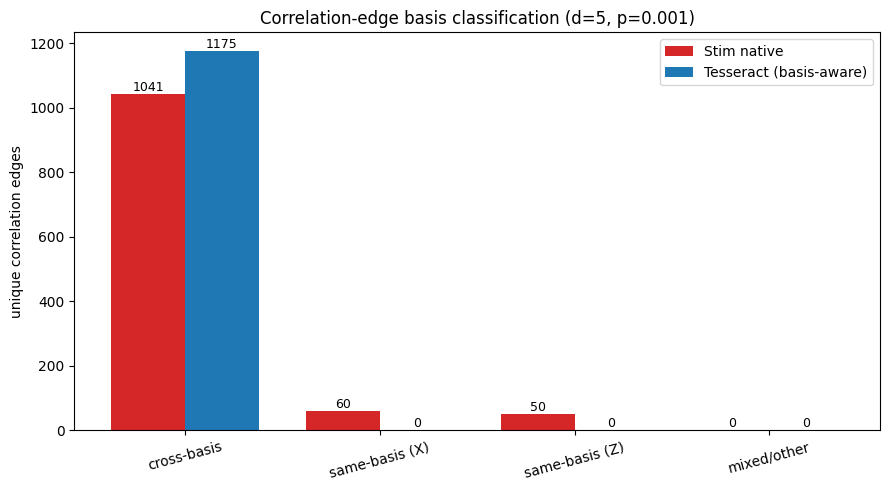

In [7]:
classes = ['cross-basis', 'same-basis (X)', 'same-basis (Z)', 'mixed/other']
stim_counts = [res_stim['corr_class'].get(c, 0) for c in classes]
tess_counts = [res_tess['corr_class'].get(c, 0) for c in classes]

x = np.arange(len(classes))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, stim_counts, w, label='Stim native', color='#d62728')
ax.bar(x + w/2, tess_counts, w, label='Tesseract (basis-aware)', color='#1f77b4')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=15)
ax.set_ylabel('unique correlation edges')
ax.set_title(f'Correlation-edge basis classification (d={DISTANCE}, p={P})')
for i, v in enumerate(stim_counts):
    ax.text(x[i]-w/2, v, str(v), ha='center', va='bottom', fontsize=9)
for i, v in enumerate(tess_counts):
    ax.text(x[i]+w/2, v, str(v), ha='center', va='bottom', fontsize=9)
ax.legend()
fig.tight_layout()
plt.show()

## Interpretation

- **Tesseract (basis-aware) decomposition:** every correlated error has at most one
  component per basis, so all correlation edges are **cross-basis (X-Z)** - the
  same-qubit Y-error mechanism. The `same-basis` columns should be **zero**.
- **Stim native decomposition:** components are only required to be graphlike, with no
  basis constraint, so it can split an error into two same-basis edges, producing
  **same-basis correlation edges** (X-X or Z-Z). Any nonzero `same-basis` count confirms
  this.

If the bars match the hypothesis, this is direct evidence that the low-p misbehaviour of
correlated matching under Stim-native decomposition is (at least partly) driven by
spurious same-subgraph correlations that the basis-aware decomposition removes.

## Mechanisms behind cross-basis hyperedges

The cross-basis correlations come from *undecomposed* errors that flip detectors in
**both** bases. Here we use `circuit.explain_detector_error_model_errors` to trace each
such error back to the physical fault (gate, Pauli, qubits) that produces it, and check
whether a cross-basis hyperedge is always a simple single-qubit **Y on a data qubit**
(X and Z in the **same round**) or whether other mechanisms contribute.

In [8]:
from collections import Counter

# Trace every DEM error mechanism back to a representative circuit-level cause.
explained = circuit.explain_detector_error_model_errors(
    reduce_to_one_representative_error=True
)
print("explained error mechanisms:", len(explained))

def coord_basis(c):
    return 'X' if detector_coord_to_basis_for_stim_surface_code_convention(c) == 0 else 'Z'

def pauli_of(gate_target):
    if gate_target.is_x_target: return 'X'
    if gate_target.is_y_target: return 'Y'
    if gate_target.is_z_target: return 'Z'
    return '?'

def loc_gate(loc):
    it = loc.instruction_targets
    g = getattr(it, 'gate', None)
    if g:
        return g
    s = str(it)
    return s.split('(')[0].split()[0] if s else 'unknown'

def describe(loc):
    pp = loc.flipped_pauli_product
    paulis = ''.join(pauli_of(t.gate_target) for t in pp)
    return loc_gate(loc), len(pp), paulis

explained error mechanisms: 1677


In [9]:
gate_counter = Counter()
mech_counter = Counter()
mech_round_counter = Counter()
examples = {}
n_cross = 0

for e in explained:
    dets = [t for t in e.dem_error_terms if t.dem_target.is_relative_detector_id()]
    coords = [list(t.coords) for t in dets]
    bases = {coord_basis(c) for c in coords if len(c) >= 2}
    if not ('X' in bases and 'Z' in bases):
        continue  # keep only cross-basis hyperedges
    n_cross += 1

    rounds = {round(c[2]) for c in coords if len(c) > 2}
    span = 'same-round' if len(rounds) == 1 else f'spans {len(rounds)} rounds'

    locs = e.circuit_error_locations
    if not locs:
        gate, nq, paulis, mech = None, 0, '', 'no-location'
    else:
        gate, nq, paulis = describe(locs[0])
        if nq == 1 and paulis == 'Y':
            mech = 'single-qubit Y'
        elif nq == 1:
            mech = f'single-qubit {paulis}'
        elif nq == 2:
            mech = f'two-qubit {paulis}'
        else:
            mech = f'{nq}-qubit {paulis}'

    gate_counter[gate] += 1
    mech_counter[mech] += 1
    mech_round_counter[(mech, span)] += 1
    cat = (mech, span)
    if cat not in examples and locs:
        examples[cat] = str(e)

print(f"cross-basis undecomposed errors: {n_cross}\n")
print("by causing gate:")
for g, n in gate_counter.most_common():
    print(f"    {str(g):18s}: {n}")
print("\nby Pauli mechanism:")
for m, n in mech_counter.most_common():
    print(f"    {m:18s}: {n}")
print("\nby mechanism x round span:")
for k, n in sorted(mech_round_counter.items()):
    print(f"    {k[0]:18s} {k[1]:16s}: {n}")

cross-basis undecomposed errors: 1175

by causing gate:
    DEPOLARIZE2       : 1175

by Pauli mechanism:
    single-qubit Y    : 571
    two-qubit XY      : 124
    two-qubit XZ      : 122
    two-qubit ZX      : 120
    two-qubit YZ      : 120
    two-qubit YY      : 118

by mechanism x round span:
    single-qubit Y     same-round      : 130
    single-qubit Y     spans 2 rounds  : 441
    two-qubit XY       same-round      : 14
    two-qubit XY       spans 2 rounds  : 110
    two-qubit XZ       same-round      : 60
    two-qubit XZ       spans 2 rounds  : 62
    two-qubit YY       same-round      : 58
    two-qubit YY       spans 2 rounds  : 60
    two-qubit YZ       same-round      : 12
    two-qubit YZ       spans 2 rounds  : 108
    two-qubit ZX       spans 2 rounds  : 120


In [10]:
# One representative circuit-level explanation per (mechanism, round-span) category.
for cat, txt in examples.items():
    print("=" * 70)
    print(f"category: {cat[0]} | {cat[1]}")
    print(txt)
    print()

category: single-qubit Y | spans 2 rounds
ExplainedError {
    dem_error_terms: D2[coords 2,2,0] D12[coords 2,0,1] D14[coords 2,2,1]
    CircuitErrorLocation {
        flipped_pauli_product: Y13[coords 2,2]
        Circuit location stack trace:
            (after 3 TICKs)
            at instruction #63 (DEPOLARIZE2) in the circuit
            at targets #25 to #26 of the instruction
            resolving to DEPOLARIZE2(0.001) 3[coords 3,1] 13[coords 2,2]
    }
}

category: two-qubit XY | spans 2 rounds
ExplainedError {
    dem_error_terms: D2[coords 2,2,0] D12[coords 2,0,1] D19[coords 0,4,1]
    CircuitErrorLocation {
        flipped_pauli_product: X12[coords 1,3]*Y13[coords 2,2]
        Circuit location stack trace:
            (after 4 TICKs)
            at instruction #66 (DEPOLARIZE2) in the circuit
            at targets #21 to #22 of the instruction
            resolving to DEPOLARIZE2(0.001) 12[coords 1,3] 13[coords 2,2]
    }
}

category: two-qubit ZX | spans 2 rounds
Explained

### Takeaways

Cross-basis hyperedges are **not** all the textbook "single Y on a data qubit, with X and
Z detected in the same round". For this d=5, p=1e-3 circuit (1175 cross-basis hyperedges):

- **Mechanism (representative cause):** only about half (571 / 1175) are explained by an
  effective single-qubit **Y**; the rest are genuine **two-qubit Pauli** errors
  (XY, XZ, ZX, YZ, YY ~120 each) where *both* qubits of a 2-qubit gate take a non-identity
  Pauli. So roughly half the cross-basis correlations come from correlated two-qubit
  faults, not a lone data-qubit Y.
- **Timing:** the clean same-round picture is the *minority* - only ~274 / 1175 hyperedges
  are same-round; the other ~901 **span two rounds**. Even among the single-qubit-Y
  mechanisms, 441 span two rounds vs only 130 same-round: a Y injected partway through the
  syndrome-extraction cycle has its X- and Z-detection events recorded in *different*
  rounds.
- **Gate attribution:** Stim's representative for every cross-basis error here is a
  `DEPOLARIZE2` location (the 2-qubit depolarizing channel after the CNOTs). This is the
  *representative* cause only - a single-qubit-Y effect also arises as the IY/YI component
  of `DEPOLARIZE2`, and the same detector set could equally be produced by
  `before_round_data_depolarization`; Stim just reports one representative. The Pauli
  content and round-span above are the robust, representative-independent facts.

**Conclusion:** the cross-basis correlation that correlated matching exploits is a genuine
*spacetime* effect - dominated by 2-qubit-gate depolarizing noise and, more often than
not, split across two rounds - which is richer than the single-qubit same-round Y picture.

## Same-basis edges under Stim: mechanism, and how Tesseract handles them

The same-basis (X-X / Z-Z) correlations only appear under Stim's native decomposition.
Here we (1) identify each unique same-basis correlation edge, (2) trace the underlying
*undecomposed* error to its physical mechanism, and (3) look up how the **tesseract**
decomposition splits the **same underlying error** (matched by its undecomposed detector
set). This shows what Stim is doing differently and what the basis-aware decomposition
does instead.

In [11]:
from adaptiveQRL.decompose_errors import undecomposed_error_detectors_and_observables

# undecomposed detector-set -> tesseract components (how tesseract splits that error)
tess_decomp = {}
for inst in dem_tess.flattened():
    if inst.type != 'error':
        continue
    dets, _ = undecomposed_error_detectors_and_observables(inst)
    tess_decomp[frozenset(dets)] = parse_components(inst)

# undecomposed detector-set -> representative physical mechanism
mech_by_set = {}
for e in explained:
    dset = frozenset(t.dem_target.val for t in e.dem_error_terms
                     if t.dem_target.is_relative_detector_id())
    mech_by_set.setdefault(dset, e)

def mech_short(e):
    if e is None or not e.circuit_error_locations:
        return '?'
    g, nq, paulis = describe(e.circuit_error_locations[0])
    return f"{paulis} via {g}"

def tess_classify(comps):
    if comps is None:
        return 'NOT FOUND'
    bs = [component_basis(c, basis_map) for c in comps]
    n = len(comps)
    if n == 1:
        return f'1 edge ({bs[0]}): no correlation'
    pairs = [(bs[i], bs[j]) for i in range(n) for j in range(i + 1, n)]
    cross = any(a != b for a, b in pairs)
    same = any(a == b for a, b in pairs)
    kind = 'cross-basis only' if (cross and not same) else ('same-basis' if (same and not cross) else 'mixed')
    return f'{n} edges, {kind}'

print("lookups built:", len(tess_decomp), "tess errors,", len(mech_by_set), "mechanisms")

lookups built: 1677 tess errors, 1677 mechanisms


In [12]:
seen = set()
same_basis_records = []
for inst in dem_stim.flattened():
    if inst.type != 'error':
        continue
    comps = parse_components(inst)
    if len(comps) < 2:
        continue
    for i in range(len(comps)):
        for j in range(i + 1, len(comps)):
            e1, e2 = comps[i], comps[j]
            if e1 == e2:
                continue
            b1, b2 = component_basis(e1, basis_map), component_basis(e2, basis_map)
            if b1 in ('mixed', 'none') or b2 in ('mixed', 'none') or b1 != b2:
                continue
            key = tuple(sorted((e1, e2)))
            if key in seen:
                continue
            seen.add(key)
            dets, _ = undecomposed_error_detectors_and_observables(inst)
            same_basis_records.append((key, b1, frozenset(dets), tuple(sorted(dets))))

print("unique same-basis correlation edges (stim):", len(same_basis_records))

mech_counter = Counter()
tess_counter = Counter()
undec_basis_counter = Counter()
for key, b, undec, undec_sorted in same_basis_records:
    mech_counter[mech_short(mech_by_set.get(undec))] += 1
    tess_counter[tess_classify(tess_decomp.get(undec))] += 1
    bc = Counter(component_basis((d,), basis_map) for d in undec_sorted)
    undec_basis_counter[f"X:{bc.get('X', 0)} Z:{bc.get('Z', 0)}"] += 1

print("\nunderlying error mechanism (representative):")
for m, n in mech_counter.most_common():
    print(f"    {m:28s}: {n}")
print("\nundecomposed detector basis composition:")
for k, n in undec_basis_counter.most_common():
    print(f"    {k:12s}: {n}")
print("\nHOW TESSERACT DECOMPOSES THE SAME UNDERLYING ERROR:")
for k, n in tess_counter.most_common():
    print(f"    {k:26s}: {n}")

unique same-basis correlation edges (stim): 110

underlying error mechanism (representative):
    Y via DEPOLARIZE2           : 63
    Z via DEPOLARIZE2           : 11
    YY via DEPOLARIZE2          : 10
    YZ via DEPOLARIZE2          : 7
    XY via DEPOLARIZE2          : 6
    X via X_ERROR               : 5
    X via DEPOLARIZE2           : 4
    ZX via DEPOLARIZE2          : 4

undecomposed detector basis composition:
    X:2 Z:2     : 59
    X:1 Z:2     : 23
    X:2 Z:0     : 14
    X:2 Z:1     : 8
    X:0 Z:2     : 6

HOW TESSERACT DECOMPOSES THE SAME UNDERLYING ERROR:
    2 edges, cross-basis only : 90
    1 edge (X): no correlation: 14
    1 edge (Z): no correlation: 6


In [13]:
def fmt(comps):
    return ", ".join(f"{c}:{component_basis(c, basis_map)}" for c in comps)

shown = 0
for inst in dem_stim.flattened():
    if shown >= 8:
        break
    if inst.type != 'error':
        continue
    comps = parse_components(inst)
    if len(comps) < 2:
        continue
    bs = [component_basis(c, basis_map) for c in comps]
    has_same = any(bs[i] == bs[j] and bs[i] in ('X', 'Z')
                   for i in range(len(bs)) for j in range(i + 1, len(bs)))
    if not has_same:
        continue
    dets, _ = undecomposed_error_detectors_and_observables(inst)
    undec = frozenset(dets)
    print("=" * 72)
    print(f"undecomposed detectors {tuple(sorted(dets))}  "
          f"bases: {fmt([(d,) for d in sorted(dets)])}")
    print(f"  mechanism    : {mech_short(mech_by_set.get(undec))}")
    print(f"  STIM  decomp : {fmt(comps)}")
    tc = tess_decomp.get(undec)
    print(f"  TESS  decomp : {fmt(tc) if tc else 'NOT FOUND'}")
    shown += 1

undecomposed detectors (4, 14, 15, 20)  bases: (4,):Z, (14,):Z, (15,):X, (20,):X
  mechanism    : Y via DEPOLARIZE2
  STIM  decomp : (4, 14):Z, (20,):X, (15,):X
  TESS  decomp : (15, 20):X, (4, 14):Z
undecomposed detectors (4, 15, 19, 20)  bases: (4,):Z, (15,):X, (19,):Z, (20,):X
  mechanism    : XY via DEPOLARIZE2
  STIM  decomp : (4, 19):Z, (20,):X, (15,):X
  TESS  decomp : (15, 20):X, (4, 19):Z
undecomposed detectors (4, 15, 20, 21)  bases: (4,):Z, (15,):X, (20,):X, (21,):Z
  mechanism    : Y via DEPOLARIZE2
  STIM  decomp : (4, 21):Z, (20,):X, (15,):X
  TESS  decomp : (15, 20):X, (4, 21):Z
undecomposed detectors (4, 15, 20, 24)  bases: (4,):Z, (15,):X, (20,):X, (24,):Z
  mechanism    : XY via DEPOLARIZE2
  STIM  decomp : (4, 24):Z, (20,):X, (15,):X
  TESS  decomp : (15, 20):X, (4, 24):Z
undecomposed detectors (5, 24, 25, 30)  bases: (5,):Z, (24,):Z, (25,):X, (30,):X
  mechanism    : Y via DEPOLARIZE2
  STIM  decomp : (5, 24):Z, (30,):X, (25,):X
  TESS  decomp : (25, 30):X, (5, 24):

### Takeaways

All 110 same-basis correlation edges that Stim creates are **decomposition artifacts**,
not physical same-basis correlations:

- **Mechanism:** the underlying faults are ordinary - mostly an effective single-qubit Y
  (63) or a two-qubit gate Pauli (YY/YZ/XY/ZX), all via `DEPOLARIZE2`, plus a few X errors.
  The undecomposed error simply flips **two detectors of the same basis** (composition
  X:2 Z:2 in 59 cases, and purely single-basis X:2 Z:0 / X:0 Z:2 in 20 cases).
- **What Stim does:** it splits those two same-basis detectors into **two separate
  boundary edges** (e.g. {15}->boundary and {20}->boundary) instead of one edge {15,20},
  manufacturing a spurious X-X (or Z-Z) "correlation" between two halves of what is really
  a single edge. For the purely single-basis errors it invents a correlation where the
  physical picture has none.
- **What Tesseract does with the same error:** it groups same-basis detectors into a
  **single edge per basis**, giving either a clean **cross-basis pair** (one X-edge + one
  Z-edge - the genuine Y-style correlation; 90/110) or a **single edge with no
  correlation** (20/110). In every case it produces **zero** same-basis correlations.

Canonical example - error flipping {4,14}(Z) and {15,20}(X) from a data-qubit Y:

| | decomposition | correlation produced |
|---|---|---|
| **Stim** | `(4,14):Z, (15,):X, (20,):X` | spurious **X-X** between (15) and (20) |
| **Tesseract** | `(15,20):X, (4,14):Z` | only the real **X-Z** (Y) link |

This is the concrete source of the spurious intra-subgraph correlations that mislead
correlated matching under Stim-native decomposition and are absent under the basis-aware
decomposition.